# Data Cleaning and Preprocessing

## Importing Libraries

In [78]:
import warnings

warnings.filterwarnings('ignore')

In [79]:
import pandas as pd
import os
import re
import nltk
import string
import numpy as np
from huggingface_hub import login
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import dagshub
import mlflow
from dotenv import load_dotenv

## Download dataset from huggingface

In [80]:


"""# Huggingface_hub Login
login()"""

"""# Loading the dataset into a pandas dataframe
df = pd.DataFrame(load_dataset("Tobi-Bueck/customer-support-tickets")['train'])

# Saving the dataset
df.to_csv("datasets/Customer_Support_Tickets.csv")"""

df = load_dataset("Tobi-Bueck/customer-support-tickets")['train'].to_pandas()

## Data Lookup

In [81]:
# First 5 rows
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [82]:
# Last 5 rows
df.tail()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
61760,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,I would be happy to assist with the IFTTT Dock...,Problem,Technical Support,low,en,NaN,Integration,Disruption,Performance,IT,Tech Support,None,None,None
61761,Bitten um Unterstützung bei der Integration,"Sehr geehrte Kundenservice, ich möchte die Int...","Sehr geehrte [Name], vielen Dank für Ihren Kon...",Change,Technical Support,medium,de,NaN,Integration,Feature,Documentation,Tech Support,None,None,None,None
61762,None,"Hello Customer Support, I am inquiring about t...",We will send you detailed information on plans...,Request,Billing and Payments,low,en,NaN,Billing,Payment,Feature,Feedback,Sales,Lead,None,None
61763,Hilfe bei digitalen Strategie-Problemen,Die Qualität unserer digitalen Strategie-Bearb...,Um den digitalen Strategie-Impuls zu überprüfe...,Incident,Product Support,high,de,NaN,Feedback,Performance,IT,Tech Support,None,None,None,None
61764,Optimierung Ihrer Datenanalyse-Plattform erlei...,"Sehr geehrte Customer Support-Team, ich schrei...","Sehr geehrter <name>, wir antworten Ihnen auf ...",Change,Sales and Pre-Sales,medium,de,NaN,Product,Feature,Performance,Guidance,Documentation,None,None,None


In [83]:
df.describe(include='all')

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,56466,61763,48576,48587,61765,61765,61765,28587.000000,48587,48528,48356,43990,27636,13225,5968,2472
unique,46635,53364,40139,4,52,5,2,NaN,211,350,591,831,956,920,755,512
top,Problembeschreibung,Facing issues with the integration of the Smar...,Das Downtime-Fehler-Szenario wird genauer unte...,Incident,Technical Support,medium,de,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Documentation
freq,3,2,2,19444,14186,23378,33504,NaN,9156,8698,9430,10004,6904,2606,512,166
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.382027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165.962935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  object 
 1   body      61763 non-null  object 
 2   answer    48576 non-null  object 
 3   type      48587 non-null  object 
 4   queue     61765 non-null  object 
 5   priority  61765 non-null  object 
 6   language  61765 non-null  object 
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  object 
 9   tag_2     48528 non-null  object 
 10  tag_3     48356 non-null  object 
 11  tag_4     43990 non-null  object 
 12  tag_5     27636 non-null  object 
 13  tag_6     13225 non-null  object 
 14  tag_7     5968 non-null   object 
 15  tag_8     2472 non-null   object 
dtypes: float64(1), object(15)
memory usage: 7.5+ MB


## Data Cleaning

### Missing values

In [85]:
# Calculate the percentage of missing values in each row
def per_missing_values(df):
    return df.isna().mean() * 100

per_missing_values(df)

subject      8.579292
body         0.003238
answer      21.353517
type        21.335708
queue        0.000000
priority     0.000000
language     0.000000
version     53.716506
tag_1       21.335708
tag_2       21.431231
tag_3       21.709706
tag_4       28.778434
tag_5       55.256213
tag_6       78.588197
tag_7       90.337570
tag_8       95.997733
dtype: float64

### Removing rows with missing body

In [86]:
df = df[~df['body'].isna()]

In [87]:
df[df['subject'].isna()]

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
870,None,"Customer Support, I am requesting comprehensiv...",Please provide detailed integration instructio...,Request,Technical Support,high,en,52.0,Support,Documentation,Troubleshooting,Integration,Configuration,Database,Guidance,Best Practices
887,None,"Customer Support,\n\nI am reporting a critical...","<name>, I regret to hear about the security br...",Incident,Technical Support,high,en,52.0,Security,Outage,Disruption,Recovery,IT,Tech Support,None,None
888,None,Die Leistung der digitalen Kampagnen unserer M...,Überprüfen Sie die Kampagnenberichte und verei...,Incident,Customer Service,medium,de,52.0,Performance,Outage,Disruption,Recovery,Security,None,None,None
915,None,"Customer Support, drafting a request for enhan...","<name>, thank you for your email regarding the...",Change,Customer Service,medium,en,52.0,Feature,Performance,Feedback,Data Analytics,Investment,Decision Making,None,None
929,None,Customer support has received a report regardi...,We have received a report about a security inc...,Incident,Billing and Payments,high,en,52.0,Security,Malware,Outage,Disruption,Recovery,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61719,None,Looking for assistance in securing medical dat...,Can provide guidance on securing medical data ...,Request,Customer Service,medium,en,NaN,Security,Documentation,IT,Tech Support,None,None,None,None
61726,None,Ein kritischer Fehler ist während der Projektm...,Wir haben eine kritische Fehlermeldung für die...,Problem,Product Support,medium,de,NaN,Bug,Disruption,Performance,IT,Tech Support,None,None,None
61751,None,"Dear Customer Support, our agency is facing co...","<name>, we are here to assist with the connect...",Incident,Technical Support,medium,en,NaN,Network,Disruption,Hardware,Performance,IT,Tech Support,None,None
61758,None,Can you provide information on digital strateg...,I would be happy to discuss digital strategies...,Request,Billing and Payments,medium,en,NaN,Feedback,Sales,Lead,None,None,None,None,None


## Data Preprocessing

In [88]:
def clean_text(text): 
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation and remove words containing numbers.''' 
    text = text.lower() 
    text = text.replace("\\n", ' ') 
    """text = re.sub(r'\s+', ' ', text).strip() 
    text = re.sub('\[.*?\]', '', text) 
    text = re.sub('https?://\S+|www\.\S+', '', text) 
    text = re.sub('<.*?>+', '', text) 
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text) 
    text = re.sub('\w*\d\w*', '', text)""" 
    return text 

def text_preprocessing(text): 
    """ Cleaning and parsing the text. """ 
    tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+') 
    nopunc = clean_text(text) 
    tokenized_text = tokenizer.tokenize(nopunc) 
    #remove_stopwords = [w for w in tokenized_text if w not in stopwords.words('english')] 
    combined_text = ' '.join(tokenized_text) 
    return combined_text

In [89]:
# Combining the subject and body columns into a single column for text preprocessing

df['clean_subject'] = df['subject'].apply(str).apply(lambda x: text_preprocessing(x))
df['clean_body'] = df['body'].apply(str).apply(lambda x: text_preprocessing(x))

df['clean_sub_body'] = df['clean_subject'] + ' ' + df['clean_body']

In [90]:
# Combining the tag columns into a single column, making sure to drop any NaN values

cols = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

# Combine the tag columns into a single column, making sure to drop any NaN values
df['tags'] = df[cols].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)

# Adding tags to body and subject for better context in the model
df['clean_sub_body'] = df['clean_sub_body'] + " " + df['tags']

In [91]:
# Classifying the tickets into departments based on the queue column

conditions = [
    df["queue"].str.contains(
        r"technical|api|authentication|integration|engineering|support|Service Outages and Maintenance|IT & Technology/Security Operations|IT & Technology/Network Infrastructure|IT & Technology/Software Development",
        case=False,
        na=False
    ),
    df["queue"].str.contains(
        r"sales|business development|account executive|General Inquiry",
        case=False,
        na=False
    ),
    df["queue"].str.contains(
        r"billing|payment|invoice|refund|Returns and Exchanges",
        case=False,
        na=False
    ),
    df["queue"].str.contains(
        r"customer success|account management|customer care|Customer Service",
        case=False,
        na=False
    ),
    df["queue"].str.contains(
        r"legal|compliance|privacy|gdpr|Law & Government/Government Services",
        case=False,
        na=False
    ),
    df['queue'].str.contains(
        r"hr|human resources|recruitment|talent acquisition|Human Resources",
        case=False,
        na=False
    )
]

choices = [
    "Technical",
    "Sales",
    "Billing",
    "Customer Success",
    "Legal",
    "HR"
]

df["department"] = np.select(
    conditions,
    choices,
    default="Other"
)

In [92]:
(df['department'].value_counts())

department
Technical           32259
Other               10426
Customer Success     7420
Billing              7312
Sales                2522
HR                   1204
Legal                 620
Name: count, dtype: int64

# Baseline Model

## Data Preparation

In [93]:
"""vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3
)

X = vectorizer.fit_transform(df["clean_sub_body"])

le = LabelEncoder()

y = le.fit_transform(df["department"])"""

'vectorizer = TfidfVectorizer(\n    max_features=50000,\n    ngram_range=(1,2),\n    min_df=3\n)\n\nX = vectorizer.fit_transform(df["clean_sub_body"])\n\nle = LabelEncoder()\n\ny = le.fit_transform(df["department"])'

In [94]:
"""# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)"""

'# Train-test split\nX_train, X_test, y_train, y_test = train_test_split(\n    X,\n    y,\n    test_size=0.2,\n    random_state=42,\n    stratify=y\n)'

## Model Training and Evaluation

### Support Vector Machine

In [95]:
"""svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000
)

svm_tags = {
    "algorithm": "Linear SVM",
    "model_type": "LinearSVC"
}"""

'svm_model = LinearSVC(\n    C=1.0,\n    random_state=42,\n    max_iter=5000\n)\n\nsvm_tags = {\n    "algorithm": "Linear SVM",\n    "model_type": "LinearSVC"\n}'

### Logistic Regression

In [96]:
"""# Model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_tags = {
    'max_iter': 1000,
    'class_weight': 'balanced'
}"""

'# Model\nlr_model = LogisticRegression(\n    max_iter=1000,\n    class_weight="balanced",\n    random_state=42\n)\n\nlr_tags = {\n    \'max_iter\': 1000,\n    \'class_weight\': \'balanced\'\n}'

### Naive Bayes

In [97]:
"""nb_model = MultinomialNB()"""

'nb_model = MultinomialNB()'

### Evaluation Plots

In [98]:
# ---------------------------------------------
# ROC Curve Function
# ---------------------------------------------

def create_roc_curve(model, model_name, X_test, y_test):

    n_classes = len(le.classes_)

    # Get prediction scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)

    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    else:
        raise ValueError(
            f"{type(model).__name__} does not support "
            "predict_proba or decision_function."
        )

    # ======================
    # Binary Classification
    # ======================
    if n_classes == 2:

        if y_score.ndim > 1:
            y_score_binary = y_score[:, 1]
        else:
            y_score_binary = y_score

        fpr, tpr, _ = roc_curve(
            y_test,
            y_score_binary
        )

        roc_auc = auc(fpr, tpr)

        fig, ax = plt.subplots(figsize=(7, 5))

        ax.plot(
            fpr,
            tpr,
            lw=2,
            label=f"AUC = {roc_auc:.3f}"
        )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            label="Random Classifier"
        )

    # ======================
    # Multiclass Classification
    # ======================
    else:

        # One-hot encode y_test
        y_test_bin = label_binarize(
            y_test,
            classes=np.arange(n_classes)
        )

        roc_auc = roc_auc_score(
            y_test_bin,
            y_score,
            multi_class="ovr",
            average="weighted"
        )

        fig, ax = plt.subplots(figsize=(8, 6))

        for i in range(n_classes):

            fpr, tpr, _ = roc_curve(
                y_test_bin[:, i],
                y_score[:, i]
            )

            class_auc = auc(fpr, tpr)

            ax.plot(
                fpr,
                tpr,
                lw=1.5,
                label=f"{le.classes_[i]} (AUC={class_auc:.3f})"
            )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            label="Random Classifier"
        )

    # ======================
    # Common Plot Formatting
    # ======================
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {model_name}")

    ax.legend(
        loc="lower right",
        fontsize=8
    )

    plt.tight_layout()

    # Save plot
    save_dir = os.path.join(
        "Images",
        "ROC_Curves"
    )

    os.makedirs(
        save_dir,
        exist_ok=True
    )

    save_path = os.path.join(
        save_dir,
        f"{model_name}.png"
    )

    fig.savefig(
        save_path,
        dpi=150
    )

    plt.close(fig)

    print(
        f"ROC Curve saved → {save_path} "
        f"(AUC: {roc_auc:.3f})"
    )

    return save_path, roc_auc

# ---------------------------------------------
# Confusion Matrix Function
# ---------------------------------------------

def create_confusion_matrix(model_name, y_true, y_pred, class_names, path="Images"):
    
    cm = confusion_matrix(y_true, y_pred)

    save_dir = os.path.join(path, "Confusion Matrix")
    os.makedirs(save_dir, exist_ok=True)

    safe_name = model_name.replace(" ", "_")
    save_path = os.path.join(save_dir, f"{safe_name}.png")

    plt.figure(figsize=(8, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()

    print(f"Confusion Matrix saved → {save_path}")

    return save_path

### Training and Evaluation

In [99]:
"""models = [
    (
        "Linear SVM",
        svm_model,
        (X_train, y_train),
        (X_test, y_test),
        {}
    ),
    (
        "Logistic Regression",
        lr_model,
        (X_train, y_train),
        (X_test, y_test),
        lr_tags
    ),
    (
        "Multinomial Naive Bayes",
        nb_model,
        (X_train, y_train),
        (X_test, y_test),
        {}
    )
]"""

'models = [\n    (\n        "Linear SVM",\n        svm_model,\n        (X_train, y_train),\n        (X_test, y_test),\n        {}\n    ),\n    (\n        "Logistic Regression",\n        lr_model,\n        (X_train, y_train),\n        (X_test, y_test),\n        lr_tags\n    ),\n    (\n        "Multinomial Naive Bayes",\n        nb_model,\n        (X_train, y_train),\n        (X_test, y_test),\n        {}\n    )\n]'

In [100]:
"""model_reports = []
model_roc_paths = []
model_roc_auc_scores = []
model_cm_path = []

for model_name, model, train_set, test_set, tags in models:

    # Unpack train and test sets
    X_train, y_train = train_set
    X_test, y_test = test_set

    # Model Training
    model.fit(X_train, y_train)

    print(f"{model_name} trained successfully!")

    # Predictions and Evaluation
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    model_reports.append(report)

    # ROC Curve
    roc_path, roc_auc = create_roc_curve(model, model_name, X_test, y_test)
    model_roc_paths.append(roc_path)
    model_roc_auc_scores.append(roc_auc)
    print(f"{model_name} ROC AUC saved successfully!")

    # Confusion Matrix
    cm_path = create_confusion_matrix(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred,
        class_names=le.classes_
    )
    model_cm_path.append(cm_path)

    print(f"{model_name} Confusion Matrix saved successfully!")
    print("--------------------------------------------------------")"""

'model_reports = []\nmodel_roc_paths = []\nmodel_roc_auc_scores = []\nmodel_cm_path = []\n\nfor model_name, model, train_set, test_set, tags in models:\n\n    # Unpack train and test sets\n    X_train, y_train = train_set\n    X_test, y_test = test_set\n\n    # Model Training\n    model.fit(X_train, y_train)\n\n    print(f"{model_name} trained successfully!")\n\n    # Predictions and Evaluation\n    y_pred = model.predict(X_test)\n    report = classification_report(y_test, y_pred, output_dict=True)\n    model_reports.append(report)\n\n    # ROC Curve\n    roc_path, roc_auc = create_roc_curve(model, model_name, X_test, y_test)\n    model_roc_paths.append(roc_path)\n    model_roc_auc_scores.append(roc_auc)\n    print(f"{model_name} ROC AUC saved successfully!")\n\n    # Confusion Matrix\n    cm_path = create_confusion_matrix(\n        model_name=model_name,\n        y_true=y_test,\n        y_pred=y_pred,\n        class_names=le.classes_\n    )\n    model_cm_path.append(cm_path)\n\n    pr

### Model Tracking in Dagshub

In [101]:
"""

dagshub.init(repo_owner='JS-Tharun', repo_name='Customer-Support-Automation', mlflow=True)

load_dotenv()

os.environ['MLFLOW_TRACKING_USERNAME'] = f"{os.getenv('MLFLOW_USERNAME')}"
os.environ['MLFLOW_TRACKING_PASSWORD'] = f"{os.getenv('MLFLOW_PASSWORD')}"

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
mlflow.set_experiment(os.environ["MLFLOW_EXPERIMENT_NAME"])

for i, element in enumerate(models):
    model_name = element[0]
    model = element[1]
    X_train, y_train = element[2]
    X_test, y_test = element[3]
    model_tags = element[4]

    model_report = model_reports[i]
    model_roc_auc = model_roc_auc_scores[i]
    roc_path = model_roc_paths[i]

    with mlflow.start_run(run_name=model_name):

        # Log model parameters
        mlflow.set_tags(tags)

        mlflow.sklearn.log_model(model, model_name)

        # Log Model performance metrics
        mlflow_metrics = {}
        for label, metrics in model_report.items():
            if isinstance(metrics, dict):  # class-wise or avg metrics
                for metric_name, value in metrics.items():
                    if metric_name != "support":  # optional: skip support (not a metric)
                        key = f"{label}_{metric_name}"
                        mlflow_metrics[key] = float(value)
            else:
                # accuracy case (single value)
                mlflow_metrics[label] = float(metrics)
        mlflow.log_metrics(mlflow_metrics)

        # Log ROC AUC metric
        mlflow_metrics["roc_auc"] = float(model_roc_auc)   # ← AUC as a metric
        mlflow.log_metrics(mlflow_metrics)
        print("Metrics Logged")

        # Log ROC AUC curve image
        mlflow.log_artifact(roc_path, artifact_path="plots/ROC AUC Curve")

        # Log Confusion matrix image
        mlflow.log_artifact(model_cm_path[i], artifact_path="plots/Confusion Matrix")
"""

'\n\ndagshub.init(repo_owner=\'JS-Tharun\', repo_name=\'Customer-Support-Automation\', mlflow=True)\n\nload_dotenv()\n\nos.environ[\'MLFLOW_TRACKING_USERNAME\'] = f"{os.getenv(\'MLFLOW_USERNAME\')}"\nos.environ[\'MLFLOW_TRACKING_PASSWORD\'] = f"{os.getenv(\'MLFLOW_PASSWORD\')}"\n\nmlflow.set_tracking_uri(os.environ[\'MLFLOW_TRACKING_URI\'])\nmlflow.set_experiment(os.environ["MLFLOW_EXPERIMENT_NAME"])\n\nfor i, element in enumerate(models):\n    model_name = element[0]\n    model = element[1]\n    X_train, y_train = element[2]\n    X_test, y_test = element[3]\n    model_tags = element[4]\n\n    model_report = model_reports[i]\n    model_roc_auc = model_roc_auc_scores[i]\n    roc_path = model_roc_paths[i]\n\n    with mlflow.start_run(run_name=model_name):\n\n        # Log model parameters\n        mlflow.set_tags(tags)\n\n        mlflow.sklearn.log_model(model, model_name)\n\n        # Log Model performance metrics\n        mlflow_metrics = {}\n        for label, metrics in model_report.

# LSTM Model

## Dataset Preparation

In [102]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Word Tokenization
MAX_WORDS = 20000
MAX_SEQ_LEN = 200
EMBEDDING_DIM = 100
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(df['clean_sub_body'].values)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 39805 unique tokens.


In [103]:
# Paddding the sequences to ensure uniform input length for the model
X = tokenizer.texts_to_sequences(df['clean_sub_body'].values)
X = pad_sequences(X, maxlen=MAX_SEQ_LEN)
print('Shape of data tensor:', X.shape)

Y = pd.get_dummies(df['department']).values
print('Shape of label tensor:', Y.shape)

Shape of data tensor: (61763, 200)
Shape of label tensor: (61763, 7)


### Train Test Split

In [104]:
#Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.10, random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(55586, 200) (55586, 7)
(6177, 200) (6177, 7)


## Model Training

In [105]:
#The first layer is the embedded layer that uses 100 length vectors to represent each word.
#SpatialDropout1D performs variational dropout in NLP models.
#The next layer is the LSTM layer with 100 memory units.
#The output layer must create 13 output values, one for each class.
#Activation function is softmax for multi-class classification.
#Because it is a multi-class classification problem, categorical_crossentropy is used as the loss function.

from keras.models import Sequential
from keras.layers import Embedding,SpatialDropout1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, dropout=0.2))
model.add(Dense(7, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

epochs = 20
batch_size = 256

history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.1,callbacks=[EarlyStopping(monitor='val_loss', patience=3, min_delta=0.001)])

Epoch 1/20
196/196 [==============================] - 11s 34ms/step - loss: 1.0214 - accuracy: 0.6720 - val_loss: 0.8517 - val_accuracy: 0.7203
Epoch 2/20
196/196 [==============================] - 6s 32ms/step - loss: 0.8070 - accuracy: 0.7330 - val_loss: 0.8161 - val_accuracy: 0.7251
Epoch 3/20
196/196 [==============================] - 6s 32ms/step - loss: 0.7345 - accuracy: 0.7507 - val_loss: 0.7707 - val_accuracy: 0.7338
Epoch 4/20
196/196 [==============================] - 6s 32ms/step - loss: 0.6639 - accuracy: 0.7701 - val_loss: 0.7475 - val_accuracy: 0.7447
Epoch 5/20
196/196 [==============================] - 6s 33ms/step - loss: 0.6238 - accuracy: 0.7859 - val_loss: 0.7108 - val_accuracy: 0.7568
Epoch 6/20
196/196 [==============================] - 7s 33ms/step - loss: 0.5451 - accuracy: 0.8142 - val_loss: 0.7140 - val_accuracy: 0.7706
Epoch 7/20
196/196 [==============================] - 7s 34ms/step - loss: 0.5142 - accuracy: 0.8258 - val_loss: 0.7155 - val_accuracy: 0.771

In [106]:
accr = model.evaluate(X_test,Y_test)
print('Test set\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr[0],accr[1]))

194/194 [==============================] - 2s 10ms/step - loss: 0.6675 - accuracy: 0.8120
Test set
  Loss: 0.668
  Accuracy: 0.812


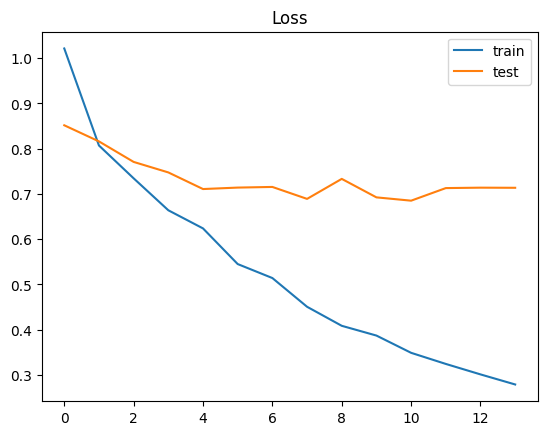

In [107]:
import matplotlib.pyplot as plt
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show();

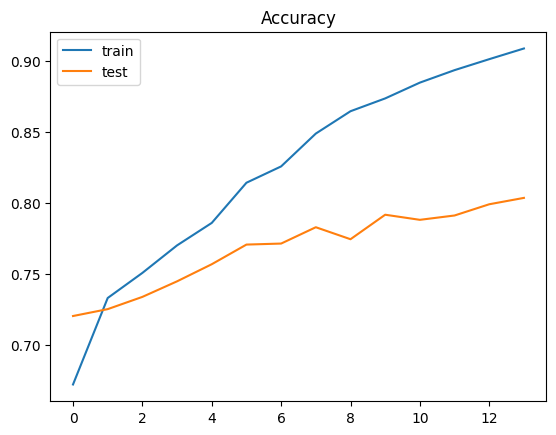

In [108]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show();

In [120]:
#Testing with new custom complaint
import numpy as np

new_complaint = ['I am unable to log in to my account. The system keeps showing a login error even after resetting my password. Please help me access my account.']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=MAX_SEQ_LEN)
pred = model.predict(padded)
labels = pd.get_dummies(df['department']).columns
print(pred, labels[np.argmax(pred)])

1/1 [==============================] - 0s 25ms/step
[[3.1451136e-03 1.5828089e-03 1.5965517e-03 2.4945932e-05 2.1824283e-04
  3.9282325e-04 9.9303955e-01]] Technical
